In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [2]:
from lm_saes import SparseAutoEncoder, LowRankSparseAttention
from transformer_lens import HookedTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from IPython.display import SVG, display

import torch
import chess

import json
from pathlib import Path
import os
import sys
from typing import Optional, Dict, Any, Tuple, List, Set

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))


from datasets import load_from_disk
import random


import numpy as np
from tqdm.auto import tqdm

from src.chess_utils import get_feature_vector, get_pos_from_square, get_piece_type_pos, feature_frequency_with_piece_type

In [3]:
model_name = 'lc0/BT4-1024x15x32h'
model = HookedTransformer.from_pretrained_no_processing(
    model_name,
    dtype=torch.float32,
).eval()

transcoders = {
    layer: SparseAutoEncoder.from_pretrained(
        f'/inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/result_BT4/tc/k_30_e_16/L{layer}',
        dtype=torch.float32,
        device='cuda',
    )
    for layer in range(15)
}

lorsas = [
    LowRankSparseAttention.from_pretrained(
        f'/inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/result_BT4/lorsa/k_30_e_16/L{layer}',
        dtype=torch.float32,
        device='cuda',
    )
    for layer in range(15)
]


state_dict keys: dict_keys(['embed.ma_gating_mul', 'embed.ma_gating_add', 'embed.ffn_alpha', 'embed.embedding_preprocess.weight', 'embed.embedding_preprocess.bias', 'embed.main_linear.weight', 'embed.main_linear.bias', 'embed.ffn_dense1.weight', 'embed.ffn_dense1.bias', 'embed.ffn_dense2.weight', 'embed.ffn_dense2.bias', 'embed.ln.weight', 'embed.ln.bias', 'embed.ln2.weight', 'embed.ln2.bias', 'blocks.0.alpha_input', 'blocks.0.alpha_out1', 'blocks.0.mha.qk_scale', 'blocks.0.mha.q_proj.weight', 'blocks.0.mha.q_proj.bias', 'blocks.0.mha.k_proj.weight', 'blocks.0.mha.k_proj.bias', 'blocks.0.mha.v_proj.weight', 'blocks.0.mha.v_proj.bias', 'blocks.0.mha.out_proj.weight', 'blocks.0.mha.out_proj.bias', 'blocks.0.mha.smolgen.compress.weight', 'blocks.0.mha.smolgen.dense1.weight', 'blocks.0.mha.smolgen.dense1.bias', 'blocks.0.mha.smolgen.ln1.weight', 'blocks.0.mha.smolgen.ln1.bias', 'blocks.0.mha.smolgen.dense2.weight', 'blocks.0.mha.smolgen.dense2.bias', 'blocks.0.mha.smolgen.ln2.weight', 'blo

[fill_missing_keys] missing_keys: {'pos_embed.W_pos', 'policy_head.promotion_weight'}
Loaded pretrained model lc0/BT4-1024x15x32h into HookedTransformer


/inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/.venv/lib/python3.11/site-packages/torch/distributed/checkpoint/state_dict_loader.py:153: UserWarning: torch.distributed is disabled, unavailable or uninitialized, assuming the intent is to load in a single process.
  warnings.warn(


In [4]:

dataset_path = "/inspire/hdd/global_user/hezhengfu-240208120186/data/rlin_data/Chess/chess_master_data"

dataset = load_from_disk(dataset_path)

dataset_size = len(dataset)
print(f"length of dataset:{dataset_size}")

random_indices = random.sample(range(dataset_size), min(500, dataset_size))
random_data = [dataset[i]['fen'] for i in random_indices]

for i, item in enumerate(random_data[:5]):
    print(f"Sample {i+1}: {item}")
    
print(f'{len(random_data) = }')

length of dataset:51541318
Sample 1: 8/1r5k/1p4pp/rP1R1p2/4pP2/P1RpP3/6KP/8 b - - 5 41
Sample 2: 6k1/p3q1pp/1r2p3/2bpP1N1/b1p1pP2/2P1P3/P2Q2PP/R1B4K w - - 2 23
Sample 3: 2B5/1P4kp/6p1/3Pp3/1q6/5RP1/5BKP/8 w - - 2 48
Sample 4: 8/5K1k/r6P/8/8/8/7R/8 b - - 28 62
Sample 5: 2r1qk2/pb3pp1/1pn4p/3p1Bb1/8/P1NQ1N2/1P3PPP/3R2K1 b - - 1 20
len(random_data) = 500


In [5]:
fen = "r1bqr1k1/pp1nbpp1/2p2n2/6P1/2BP4/P7/1PQNNPP1/R3K2R b KQ - 0 13"

fen_list = [fen]

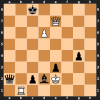

Pawns in front of own king: [50]


In [6]:
def get_pawns_in_front_of_own_king(fen: str) -> list[int]:
    """获取己方王前面的兵的位置。
    
    Args:
        fen: FEN字符串
    
    Returns:
        王前面的兵的位置列表（已翻转，适用于模型输入）
    """
    board = chess.Board(fen)
    side_to_move = board.turn
    
    king_square = board.king(side_to_move)
    if king_square is None:
        return []
    
    king_file = chess.square_file(king_square)
    king_rank = chess.square_rank(king_square)
    
    pawns_in_front = []
    pawns = board.pieces(chess.PAWN, side_to_move)
    
    for pawn_square in pawns:
        pawn_file = chess.square_file(pawn_square)
        pawn_rank = chess.square_rank(pawn_square)
        
        if pawn_file == king_file:
            if side_to_move == chess.WHITE:
                if pawn_rank > king_rank:
                    pawns_in_front.append(pawn_square)
            else:
                if pawn_rank < king_rank:
                    pawns_in_front.append(pawn_square)
    
    if not pawns_in_front:
        return []
    
    if board.turn == chess.BLACK:
        flipped = []
        for sq in pawns_in_front:
            file_idx = chess.square_file(sq)
            rank_idx = chess.square_rank(sq)
            flipped.append(chess.square(file_idx, 7 - rank_idx))
        return flipped
    
    return pawns_in_front

fen_test = "2k5/4Q3/3P4/8/6p1/4p3/q1pbK3/1R6 b - - 0 32"
board = chess.Board(fen_test)
svg_board = chess.svg.board(board=board, size=100)
display(SVG(svg_board))
print("Pawns in front of own king:", get_pawns_in_front_of_own_king(fen_test))

In [7]:
# 对于每一个feature_type, layer, feature_id，聚合所有fen的统计信息
# - 激活的是 "己方王前面的兵" 的 token 个数（累积）
# - 激活的不是 "己方王前面的兵" 的 token 个数（累积）
# - 总的 token 个数（累积）
# - 激活频率 = 激活token总数 / 总token数
# - 激活的 "己方王前面的兵" token 占总的 "己方王前面的兵" token 的比例
# - IOU: 激活且为该 piece 的 token 数 / (该 piece 的 token 总数 + 激活的非该 piece token 数)
# - F1 = 2TP / (2TP + FP + FN)，其中 TP=active_piece, FP=active_non_piece, FN=piece_token_cnt-TP
# - Accuracy: 当feature激活时，有多少比例是在"王前面的兵"的位置 = active_piece / (active_piece + active_non_piece)


def compute_iou_stats(fen_list: list[str]):
    device = model.cfg.device

    # stats[feature_type][layer] = dict of tensors
    stats = {
        "transcoder": {},
        "lorsa": {},
    }

    for fen in tqdm(fen_list, desc="FEN loop"):
        pos_list = get_pawns_in_front_of_own_king(fen)
        if not pos_list:
            continue

        pos_mask = torch.zeros(64, dtype=torch.bool, device=device)
        pos_mask[pos_list] = True

        # 一次 forward
        _, cache = model.run_with_cache(fen, prepend_bos=False)

        for feature_type, modules in [
            ("transcoder", transcoders),
            ("lorsa", lorsas),
        ]:
            if feature_type == "transcoder":
                # transcoders 是字典，需要遍历 items
                for layer, sae in modules.items():
                    hook_name = f"blocks.{layer}.resid_mid_after_ln"
                    acts = sae.encode(cache[hook_name])
                    acts_all = acts[0] if acts.dim() == 3 else acts  # [seq, d_feat]

                    seq_len, d_feat = acts_all.shape
                    piece_mask = pos_mask[:seq_len]

                    active = acts_all > 0
                    active_piece = active & piece_mask[:, None]
                    active_non_piece = active & (~piece_mask[:, None])

                    # ===== lazy init（第一次见到该 layer）=====
                    if layer not in stats[feature_type]:
                        stats[feature_type][layer] = {
                            "active_piece": torch.zeros(d_feat, device=device),
                            "active_non_piece": torch.zeros(d_feat, device=device),
                            "active_total": torch.zeros(d_feat, device=device),
                            "piece_token_cnt": 0,
                            "total_tokens": 0,
                        }

                    s = stats[feature_type][layer]

                    # ===== 向量化累积 =====
                    s["active_piece"] += active_piece.sum(0)
                    s["active_non_piece"] += active_non_piece.sum(0)
                    s["active_total"] += active.sum(0)
                    s["piece_token_cnt"] += int(piece_mask.sum())
                    s["total_tokens"] += seq_len
            else:
                # lorsas 是列表，使用 enumerate
                for layer, sae in enumerate(modules):
                    hook_name = f"blocks.{layer}.hook_attn_in"
                    acts = sae.encode(cache[hook_name])
                    acts_all = acts[0] if acts.dim() == 3 else acts  # [seq, d_feat]

                    seq_len, d_feat = acts_all.shape
                    piece_mask = pos_mask[:seq_len]

                    active = acts_all > 0
                    active_piece = active & piece_mask[:, None]
                    active_non_piece = active & (~piece_mask[:, None])

                    # ===== lazy init（第一次见到该 layer）=====
                    if layer not in stats[feature_type]:
                        stats[feature_type][layer] = {
                            "active_piece": torch.zeros(d_feat, device=device),
                            "active_non_piece": torch.zeros(d_feat, device=device),
                            "active_total": torch.zeros(d_feat, device=device),
                            "piece_token_cnt": 0,
                            "total_tokens": 0,
                        }

                    s = stats[feature_type][layer]

                    # ===== 向量化累积 =====
                    s["active_piece"] += active_piece.sum(0)
                    s["active_non_piece"] += active_non_piece.sum(0)
                    s["active_total"] += active.sum(0)
                    s["piece_token_cnt"] += int(piece_mask.sum())
                    s["total_tokens"] += seq_len

    # ========= 统一计算 IOU / F1 =========
    results = []
    print("go into calculate loop")

    for feature_type, layers in stats.items():
        for layer, s in layers.items():
            tp = s["active_piece"]
            fp = s["active_non_piece"]
            total_active = s["active_total"]

            piece_cnt = s["piece_token_cnt"]
            total_tokens = s["total_tokens"]

            fn = torch.clamp_min(piece_cnt - tp, 0)

            iou = torch.where(
                piece_cnt + fp > 0,
                tp / (piece_cnt + fp),
                torch.zeros_like(tp),
            )

            f1 = torch.where(
                (2 * tp + fp + fn) > 0,
                2 * tp / (2 * tp + fp + fn),
                torch.zeros_like(tp),
            )

            activation_freq = total_active / max(total_tokens, 1)
            piece_ratio = tp / max(piece_cnt, 1)
            
            # Accuracy: 当feature激活时，有多少比例是在"王前面的兵"的位置
            # accuracy = active_piece / (active_piece + active_non_piece)
            accuracy = torch.where(
                total_active > 0,
                tp / total_active,
                torch.zeros_like(tp),
            )

            for fid in range(tp.numel()):
                results.append({
                    "feature_type": feature_type,
                    "layer": layer,
                    "feature_id": fid,
                    "active_piece": int(tp[fid].item()),
                    "active_non_piece": int(fp[fid].item()),
                    "active_total": int(total_active[fid].item()),
                    "total_tokens": total_tokens,
                    "piece_token_cnt": piece_cnt,
                    "activation_freq": float(activation_freq[fid].item()),
                    "piece_activation_ratio": float(piece_ratio[fid].item()),
                    "iou": float(iou[fid].item()),
                    "f1": float(f1[fid].item()),
                    "accuracy": float(accuracy[fid].item()),
                })

    return results

output_dir = Path.cwd()

print("Computing IOU/F1 for '己方王前面的兵' (pawns in front of own king)")
stats = compute_iou_stats(random_data)
stats_sorted = sorted(stats, key=lambda x: x["f1"], reverse=True)
top50 = stats_sorted[:50]

output_path = output_dir / "detection_feature_top50_pawns_in_front_of_own_king.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(top50, f, indent=2, ensure_ascii=False)
print(f"Saved top 50 to {output_path}")

print(f"Total features processed: {len(stats)}")
print(f"Top 50 features saved")


Computing IOU/F1 for '己方王前面的兵' (pawns in front of own king)


FEN loop:   0%|          | 0/500 [00:00<?, ?it/s]

go into calculate loop
Saved top 50 to /inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/exp/55Taxonomy/detection_feature_top50_pawns_in_front_of_own_king.json
Total features processed: 491520
Top 50 features saved


In [8]:
from pprint import pprint

pprint(stats_sorted[:10])

[{'accuracy': 0.6196318864822388,
  'activation_freq': 0.01442988682538271,
  'active_non_piece': 124,
  'active_piece': 202,
  'active_total': 326,
  'f1': 0.5855072736740112,
  'feature_id': 5577,
  'feature_type': 'lorsa',
  'iou': 0.4139344394207001,
  'layer': 0,
  'piece_activation_ratio': 0.5549450516700745,
  'piece_token_cnt': 364,
  'total_tokens': 22592},
 {'accuracy': 0.4736842215061188,
  'activation_freq': 0.018502123653888702,
  'active_non_piece': 220,
  'active_piece': 198,
  'active_total': 418,
  'f1': 0.5063938498497009,
  'feature_id': 8359,
  'feature_type': 'transcoder',
  'iou': 0.3390410840511322,
  'layer': 0,
  'piece_activation_ratio': 0.5439560413360596,
  'piece_token_cnt': 364,
  'total_tokens': 22592},
 {'accuracy': 0.930232584476471,
  'activation_freq': 0.005709985736757517,
  'active_non_piece': 9,
  'active_piece': 120,
  'active_total': 129,
  'f1': 0.4868154227733612,
  'feature_id': 10302,
  'feature_type': 'lorsa',
  'iou': 0.3217158317565918,
  